# 12 · Use the organizer

**Step 2.** One line reopens everything `11` built — nine samples, fifteen
techniques, four stages. From here the organizer is the only thing the work
touches.

Six parts, in the order a session actually goes:

| | |
|---|---|
| **A** | load it, look at it, carve out the samples you care about |
| **B** | load data — curves, images, a tomogram — all at once or one frame at a time |
| **C** | visualise all four kinds of data — the quick call, or your own figure |
| **D** | fit one, check it, *then* batch the same parameters across the campaign |
| **E** | compare: three routes to one composition, three sizes, and the volcano |
| **F** | reload, read the stored fits back, go round again |

The through-line is that **nothing is a dead end**. Every quick call has a
lower-level one underneath it that hands you the arrays, because the moment an
analysis is interesting it stops fitting whatever the convenience function
assumed. And analysing and drawing are always **two calls**: a result comes
back, and a plot function — which takes `ax=` like every plot here — is handed
it.

---
# A · Load the organizer and look at it

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from NanoOrganizer import Organizer
from NanoOrganizer.demo import demo_root

ROOT = demo_root("CuAu")
org = Organizer(ROOT / "cuau.json")
org

<Organizer 'Cu-Au CO2RR library': 9 samples, all — /home/yuzhang/Repos/OrgDemo/CuAu/cuau.json>

`describe()` is the first cell of a session: how many samples, what was done
to them, which techniques, what has been analysed, and how much of it is
readable *here*. No data is touched.

In [2]:
org.describe();

Cu-Au CO2RR library  (/home/yuzhang/Repos/OrgDemo/CuAu/cuau.json)
  samples       9
                CuAu01, CuAu02, CuAu03, CuAu04, CuAu05, CuAu06, CuAu07, CuAu08  … +1 more
  stages        characterization (8), computation (8), synthesis (9), testing (8)
  Curves (1D)   uvvis, eds, xps, raman, ir, saxs1d, waxs1d, xas, ec, dos, dls
  Images & Maps (2D) saxs2d, tem, sem
  Correlation   xpcs_g2
  Volumes (3D)  tomo
  measurements  144 (144 readable here, 0 not mounted)


In [3]:
# The same as a dict, when you want to branch on it rather than read it.
info = org.overview()
{k: info[k] for k in ("n_samples", "stages", "modalities", "n_measurements")}

{'n_samples': 9,
 'stages': {'characterization': 8,
  'testing': 8,
  'computation': 8,
  'synthesis': 9},
 'modalities': {'curve': ['uvvis',
   'eds',
   'xps',
   'raman',
   'ir',
   'saxs1d',
   'waxs1d',
   'xas',
   'ec',
   'dos',
   'dls'],
  'image': ['saxs2d', 'tem', 'sem'],
  'correlation': ['xpcs_g2'],
  'volume': ['tomo']},
 'n_measurements': 144}

## The structure of the file itself

`tree()` walks the organizer one layer at a time — **structure, not data** —
and walks the live session, not the last save.

In [4]:
print(org.tree(depth=2, limit=4))

📄 cuau.json  221.6 KB
├── 🔑 project  7 keys
│   ├── · name  str = Cu-Au CO2RR library
│   ├── · description  str = 
│   ├── 📋 path_aliases  1 items of dict
│   ├── 📋 extra_roots  empty
│   └── … +3 more  raise the per-layer limit to see them
└── 📋 samples  9 items of dict
    ├── 🔑 0  7 keys
    ├── 🔑 1  7 keys
    ├── 🔑 2  7 keys
    ├── 🔑 3  7 keys
    └── … +5 more  raise the per-layer limit to see them


In [5]:
# Descend into one sample's record: the address is a path inside the document,
# exactly as it is for an HDF5 group or a metadata module.
print(org.tree(address="samples/4/measurements", depth=1, limit=8))

🔑 measurements
├── 🔑 0  11 keys
├── 🔑 1  11 keys
├── 🔑 2  11 keys
├── 🔑 3  11 keys
├── 🔑 4  11 keys
├── 🔑 5  11 keys
├── 🔑 6  11 keys
├── 🔑 7  11 keys
└── … +10 more  raise the per-layer limit to see them


## Which samples are there

`catalog()` is the sample × technique matrix — sparse on purpose, with the
failed run as an empty row. `ids()` answers a question without committing to
it; `filter()` commits, and every later call follows.

In [6]:
org.catalog()

,uvvis,eds,xps,raman,ir,saxs1d,waxs1d,saxs2d,xas,xpcs_g2,ec,dos,tem,sem,dls,tomo
sample_id,,,,,,,,,,,,,,,,
CuAu01,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
CuAu02,True,True,True,True,True,True,True,False,False,False,True,True,True,True,True,False
CuAu03,True,True,True,True,True,True,True,False,True,False,True,True,True,True,True,False
CuAu04,True,True,True,True,True,True,True,True,False,True,True,True,True,True,True,False
CuAu05,True,True,True,True,True,True,True,False,True,False,True,True,True,True,True,False
CuAu06,True,True,True,True,True,True,True,False,False,False,True,True,True,True,True,True
CuAu07,True,True,True,True,True,True,True,False,True,False,True,True,True,True,True,False
CuAu08,True,True,True,True,True,True,True,True,False,True,True,True,True,True,True,False
CuAu09,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [7]:
print("all:          ", org.ids())
print("gold-rich:    ", org.ids("`synthesis.composition.nominal_x_Au` >= 0.5"))
print("CO-selective: ", org.ids("`testing.performance.FE_CO_pct` > 40"))
print("failed:       ", org.ids("`synthesis.status` == 'error'"))
# CuAu09 counts as gold-rich: its recipe said 0.50, and a recipe is what the
# table holds. Whether a failed run belongs in a comparison is your call —
# add "and `synthesis.status` == 'done'" to make it.
print("basket:       ", org.basket, "(unchanged)")

all:           ['CuAu01', 'CuAu02', 'CuAu03', 'CuAu04', 'CuAu05', 'CuAu06', 'CuAu07', 'CuAu08', 'CuAu09']
gold-rich:     ['CuAu05', 'CuAu06', 'CuAu07', 'CuAu08', 'CuAu09']
CO-selective:  ['CuAu04', 'CuAu05', 'CuAu06', 'CuAu07', 'CuAu08']
failed:        ['CuAu09']
basket:        [] (unchanged)


## Carving out a sub-organizer

An explicit list when you know which samples, a query when you know the
condition. A subset is a **deep copy**, not a view — analysing it cannot write
derived values back into the parent by accident — and nothing is written until
you call `save()`.

In [8]:
ends = org.subset(["CuAu01", "CuAu05", "CuAu08"], name="ends")
gold = org.subset(query="`synthesis.composition.nominal_x_Au` >= 0.5", name="gold_rich")

print(ends, "->", ends.project.sample_ids())
print(gold, "->", gold.project.sample_ids())
print("parent untouched:", len(org.project), "samples; written?", gold.path.exists())

<Organizer 'ends': 3 samples, all — /home/yuzhang/Repos/OrgDemo/CuAu/cuau__ends.json> -> ['CuAu01', 'CuAu05', 'CuAu08']
<Organizer 'gold_rich': 5 samples, all — /home/yuzhang/Repos/OrgDemo/CuAu/cuau__gold_rich.json> -> ['CuAu05', 'CuAu06', 'CuAu07', 'CuAu08', 'CuAu09']
parent untouched: 9 samples; written? False


---
# B · Load data

What comes back follows what the data *is*:

| group | `org.data(sample, technique)` returns |
|---|---|
| curves, correlations | `(x, Y, info)` with `Y` of shape `(n_frames, n_points)` |
| images | `(array, info)` — one frame, picked by `frame=`, `t=` or `T=` |
| volumes | `(volume, info)` |

**One frame at a time** when there are many: `lazy=True` resolves the file list
up front — so `len()`, the names and the per-frame table are there at once —
and opens a file only when a frame is indexed.

In [9]:
x, Y, info = org.data("CuAu05", "uvvis")
print("UV-Vis:  ", x.shape, Y.shape, "| times", info["t_s"][:3], "…")

q, I, _ = org.data("CuAu05", "waxs1d")
print("WAXS:    ", q.shape, I.shape)

E, FE, fe_info = org.data("CuAu05", "ec", role="co2-rr-fe")     # one file per product
print("FE:      ", E.shape, FE.shape, fe_info["labels"])

lag, g2, _ = org.data("CuAu01", "xpcs_g2")                     # a correlation function
print("XPCS g2: ", lag.shape, g2.shape)

image, meta = org.data("CuAu05", "tem", frame=1)
print("TEM:     ", image.shape, meta["file"], meta["nm_per_pixel"], "nm/px")

UV-Vis:   (551,) (14, 551) | times [ 0. 45. 90.] …
WAXS:     (1400,) (1, 1400)
FE:       (10,) (6, 10) ['FE_H2.dat', 'FE_CO.dat', 'FE_HCOO.dat', 'FE_CH4.dat', 'FE_C2H4.dat', 'FE_EtOH.dat']
XPCS g2:  (64,) (1, 64)


TEM:      (384, 384) 02.tif 0.5 nm/px


## The layer below a measurement

`frames()` is the per-file table: one row each, with whatever the filename
admitted about when (`t_s`) and how hot (`T_c`) it was taken — this growth
series was recorded on a heating ramp, so the names carry both. `t=` and `T=`
select on it, by **nearest** value.

In [10]:
org.frames("CuAu05", "uvvis")[["file", "t_s", "T_c"]].head(5)

,file,t_s,T_c
0,uvvis_b05_t00000s_T30C.npy,0.0,30.0
1,uvvis_b05_t00045s_T35C.npy,45.0,35.0
2,uvvis_b05_t00090s_T40C.npy,90.0,40.0
3,uvvis_b05_t00135s_T45C.npy,135.0,45.0
4,uvvis_b05_t00180s_T50C.npy,180.0,50.0


In [11]:
_, _, at_300s = org.data("CuAu05", "uvvis", t=300)
_, _, at_80C = org.data("CuAu05", "uvvis", T=80)
print("t=300 ->", at_300s["labels"], "   T=80 ->", at_80C["labels"])

t=300 -> ['t = 315 s']    T=80 -> ['t = 450 s']


In [12]:
frames = org.data("CuAu05", "tem", lazy=True)
print(frames)
print("known without opening anything:", len(frames), frames.names)

array, meta = frames[2]                    # one file opened, here and nowhere else
print("frame 2:", array.shape, meta["file"])

<LazyFrames CuAu05:tem:characterization image: 3 files, unread>
known without opening anything: 3 ['01.tif', '02.tif', '03.tif']
frame 2: (384, 384) 03.tif


A single file holding a 3D volume is **memory-mapped**: its frames are the
planes, and indexing one costs one plane rather than the whole tomogram.

In [13]:
planes = org.data("CuAu01", "tomo", lazy=True)
print(planes, "| planes:", len(planes))
plane, meta = planes[64]
print("one plane:", plane.shape, "| index", meta["plane"])

volume, vinfo = org.data("CuAu01", "tomo")           # and all of it, when you ask
voxel_nm = org.measurement("CuAu01", modality="tomo").meta["voxel_size_nm"]
print("whole volume:", volume.shape, f"at {voxel_nm} nm per voxel (recorded when it was linked)")

<LazyFrames CuAu01:tomo:characterization volume: 128 planes of tomogram.npy, unread> | planes: 128
one plane: (128, 128) | index 64
whole volume: (128, 128, 128) at 2.0 nm per voxel (recorded when it was linked)


---
# C · Visualise

## The quick call

`org.plot(sample, technique, ax=…)` dispatches on what the data *is* — the
modality registry says `uvvis` is a series, `tem` an image, `tomo` a volume,
`xpcs_g2` a correlation — so fifteen techniques are four code paths, and adding
a sixteenth adds none. Every call draws into the axes it is handed.

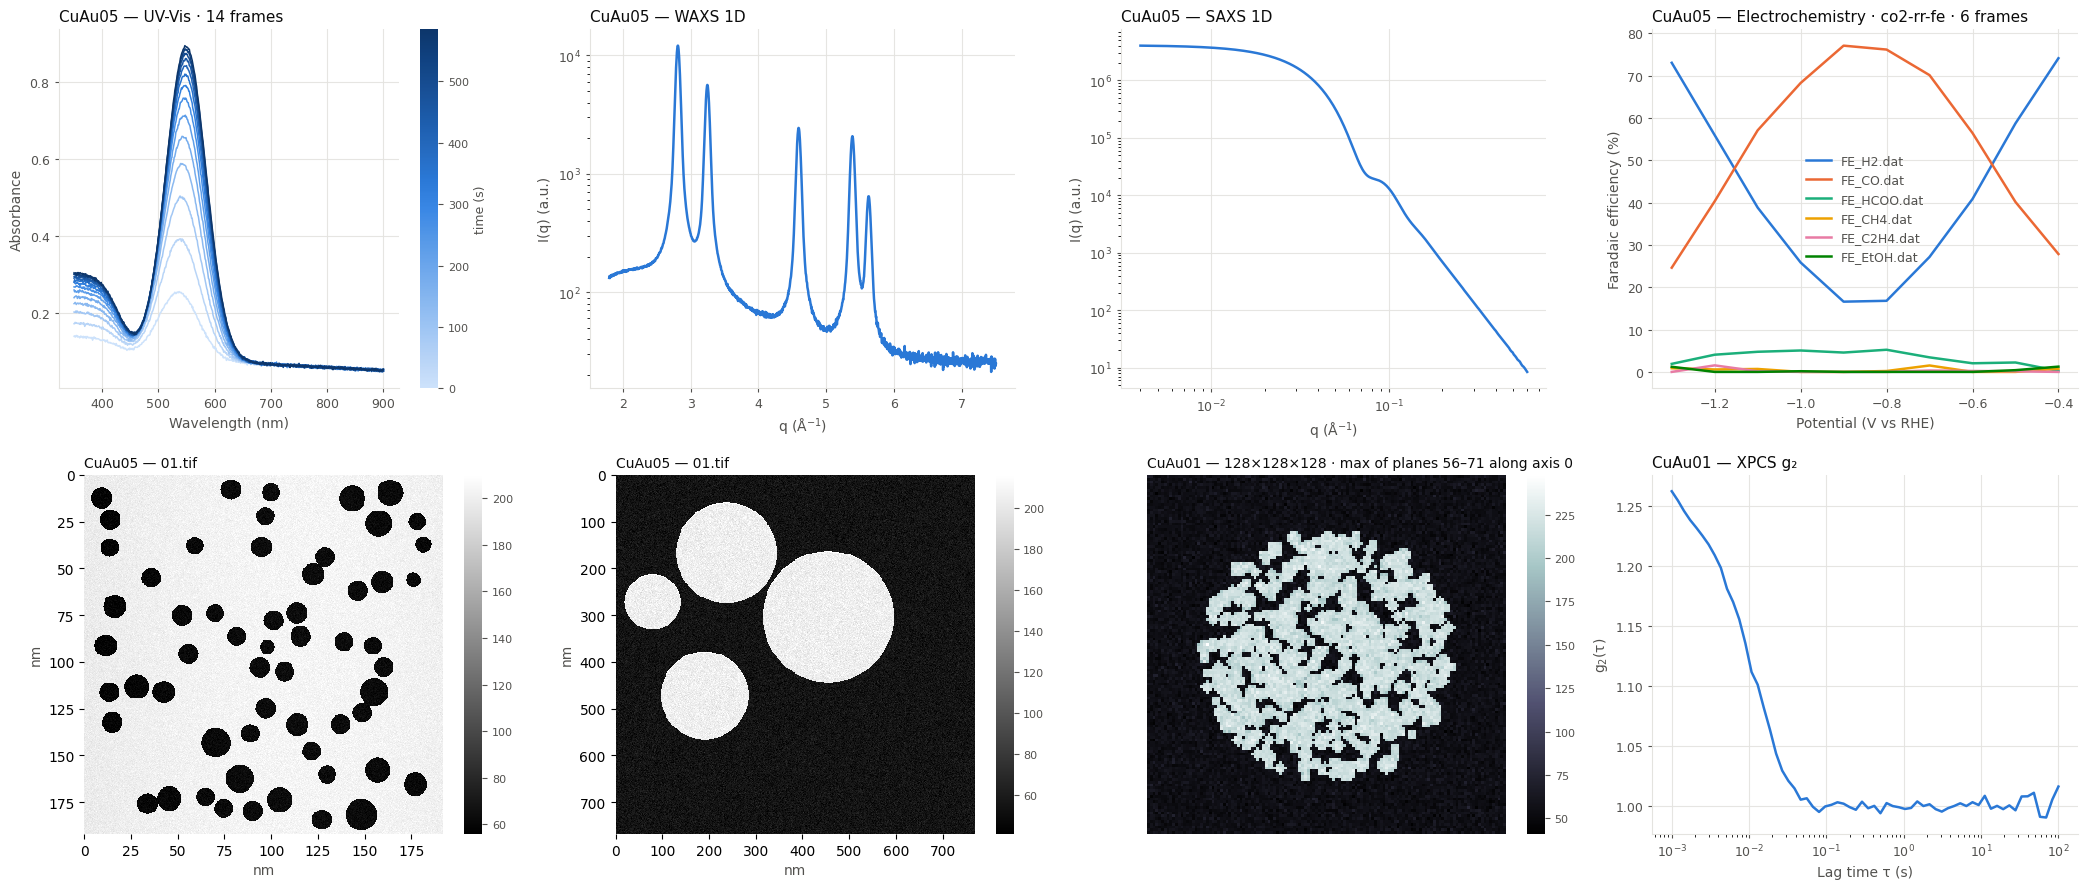

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(21, 9))
org.plot("CuAu05", "uvvis", ax=axes[0, 0])
org.plot("CuAu05", "waxs1d", ax=axes[0, 1])
org.plot("CuAu05", "saxs1d", ax=axes[0, 2])
org.plot("CuAu05", "ec", role="co2-rr-fe", ylabel="Faradaic efficiency (%)", ax=axes[0, 3])
org.plot("CuAu05", "tem", cmap="gray", ax=axes[1, 0])
org.plot("CuAu05", "sem", cmap="gray", ax=axes[1, 1])
org.plot("CuAu01", "tomo", slab=16, cmap="bone", ax=axes[1, 2])
org.plot("CuAu01", "xpcs_g2", ax=axes[1, 3])
fig.tight_layout()

Several things happened without being asked. The growth series is coloured
along **one hue by acquisition time**, with a colour bar instead of a legend of
fourteen timestamps. SAXS and XPCS came out on log axes because the registry
says that is how those are read. The micrographs are on **nanometre axes**,
because the TIFFs carried their calibration. And the tomogram is a **slab
projection** — a single plane through a porous aggregate shows one accident of
where the plane fell.

## Your own figure, from B

The quick call stops being enough about ten minutes into a real question. Then
take the arrays and draw them with the plot kernels — `plot_series`,
`plot_curves`, `plot_image` — which take arrays, draw into your axes, and
return them for more.

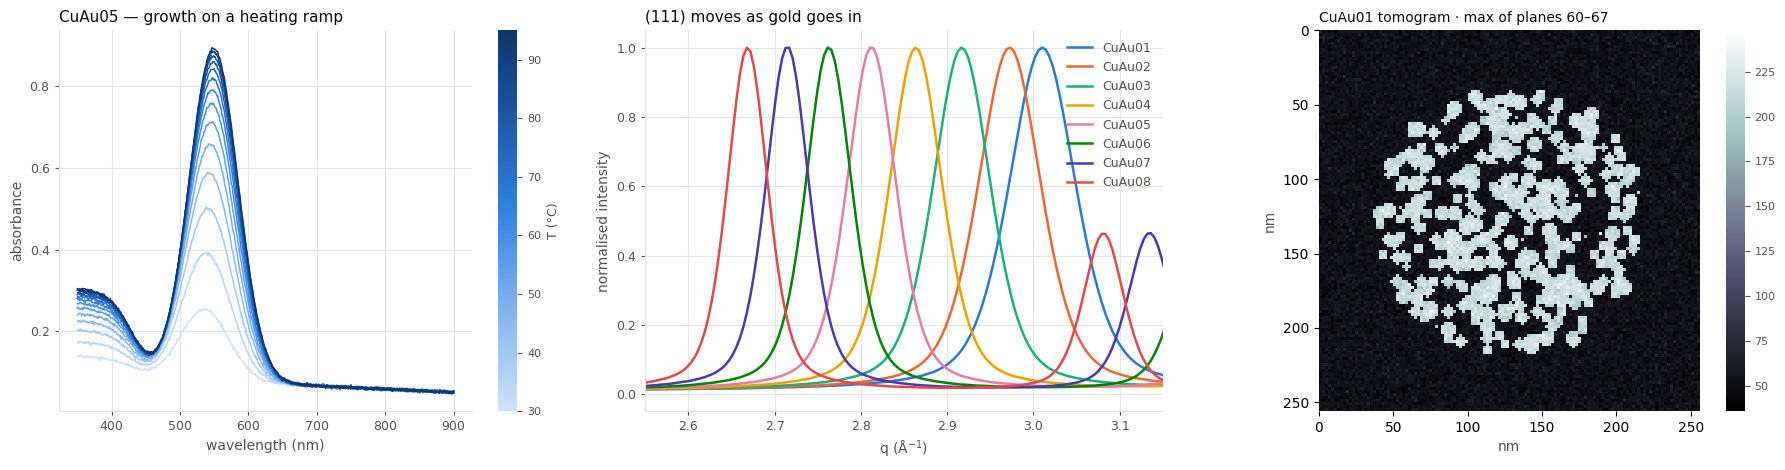

In [15]:
from NanoOrganizer.viz.plots import plot_curves, plot_image, plot_series
from NanoOrganizer.viz.show import project_volume

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

# 1. The growth series coloured by TEMPERATURE instead of time — the frame
#    table had it, and no built-in offers it.
x, Y, _ = org.data("CuAu05", "uvvis")
temperature = org.frames("CuAu05", "uvvis")["T_c"].to_numpy()
plot_series(x, Y, temperature, ax=axes[0], xlabel="wavelength (nm)",
            ylabel="absorbance", colorbar_label="T (°C)",
            title="CuAu05 — growth on a heating ramp")

# 2. The (111) reflection across the whole library: Vegard's law, by eye.
curves = []
for sample in org.ids("`synthesis.status` == 'done'"):
    q_s, I_s, _ = org.data(sample, "waxs1d")
    curves.append((sample, q_s, I_s[0] / I_s[0].max()))
plot_curves(curves, ax=axes[1], xlim=(2.55, 3.15), xlabel="q (Å$^{-1}$)",
            ylabel="normalised intensity", title="(111) moves as gold goes in")

# 3. A thinner slab through the tomogram, on nanometre axes.
plane, detail = project_volume(volume, projection="max projection", slab=8)
side = volume.shape[1] * voxel_nm
plot_image(plane, ax=axes[2], cmap="bone", extent=(0, side, side, 0),
           xlabel="nm", ylabel="nm", title=f"CuAu01 tomogram · {detail}")
fig.tight_layout()

## Turning the tomogram around

A projection says what is in there; only rotation says what shape it is. The
interactive figures are Plotly, take the same arrays, and follow the same rule
with `fig=` in place of `ax=`. Drag to rotate, scroll to zoom — and move
`level` before believing any of it, because that one number decides what the
structure appears to be.

A browser cannot take 128³ voxels, so the volume is strided down first and the
title says by how much. At that stride a single isosurface of a porous
aggregate breaks into fragments; the translucent `volume` mode degrades
gracefully, which is why it is used here. (`mode="isosurface"`, `"points"`
and `"slices"` are the other three.)

In [16]:
from NanoOrganizer.viz import interactive as iv

iv.volume_figure(volume, mode="volume", level=130, voxel_size=voxel_nm, unit="nm",
                 max_voxels=40**3, height=520, title="CuAu01 tomogram")

---
# D · Fit one, check it, then batch

Three levels, and you can enter at any of them:

| | |
|---|---|
| `fit_peaks(x, y, …)` | the **kernel** — arrays in, result out. No files, no project. |
| `org.fit(sample, technique, …)` | finds the curve for you, runs the kernel, stores nothing, draws nothing |
| `org.batch(key, link=True, …)` | the whole selection, derived columns written, fits linked back |

Settling the parameters on a sample you can **look at**, and only then spending
them on the whole set, is the same work as running the batch first and reading
its R² column afterwards — in the order that does not hide the mistake.

## The kernel: from a diffraction pattern to a composition

The (111) and (200) reflections sit close together, so fit both — pseudo-Voigt
peaks on a linear background. The (111) position gives the lattice parameter,
and Vegard's law run backwards gives the gold fraction. Both of those steps are
kernels too (`NanoOrganizer.demo.materials`), so the arithmetic exists once.

In [17]:
from NanoOrganizer.analysis import fit_peaks
from NanoOrganizer.demo import materials as mat
from NanoOrganizer.viz.plots import plot_fit

truth = pd.read_csv(ROOT / "truth.csv").set_index("sample_id")

q, I, info = org.data("CuAu05", "waxs1d")
fit = fit_peaks(q, I[0], n_peaks=2, x_range=(2.5, 3.6), shape="pseudo_voigt",
                background="linear")
fit

<PeakFitResult 2 peak(s) at [2.812, 3.247], R² = 0.9999>

(111) at 2.8123 ± 2.5e-05 Å⁻¹  →  a = 3.8698 Å  →  x(Au) = 0.550   (truth 0.550)


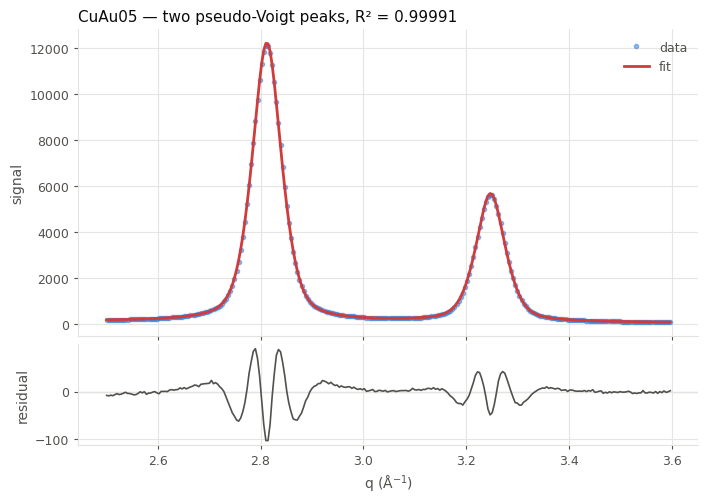

In [18]:
a = mat.lattice_from_q(fit.params["peak1_center"])
x_au = mat.fraction_from_lattice(a)
print(f"(111) at {fit.params['peak1_center']:.4f} ± {fit.errors['peak1_center']:.1e} Å⁻¹"
      f"  →  a = {a:.4f} Å  →  x(Au) = {x_au:.3f}   (truth {truth.loc['CuAu05', 'x_Au']:.3f})")

fig, ax = plt.subplots(figsize=(8, 5.4))
plot_fit(fit.x, fit.y, fit.y_fit, fit.residual, ax=ax, xlabel="q (Å$^{-1}$)",
         title=f"CuAu05 — two pseudo-Voigt peaks, R² = {fit.r2:.5f}");

## The model is a choice — and the headline number will not tell you

Nothing in that cell knew about an organizer, so trying alternatives is a loop
over the kernel. One peak forced across both reflections is the classic
mistake, and it is instructive *because* the composition survives it: a sharp
peak's position barely depends on the model. Everything else does not. The
background comes out nearly double and the width a few per cent narrow — and
those are what a crystallite size or a phase fraction would be computed from.
The residual is what says so. Because `plot_fit` draws where it is told, the
three trials sit side by side, each with its residual split off its own panel.

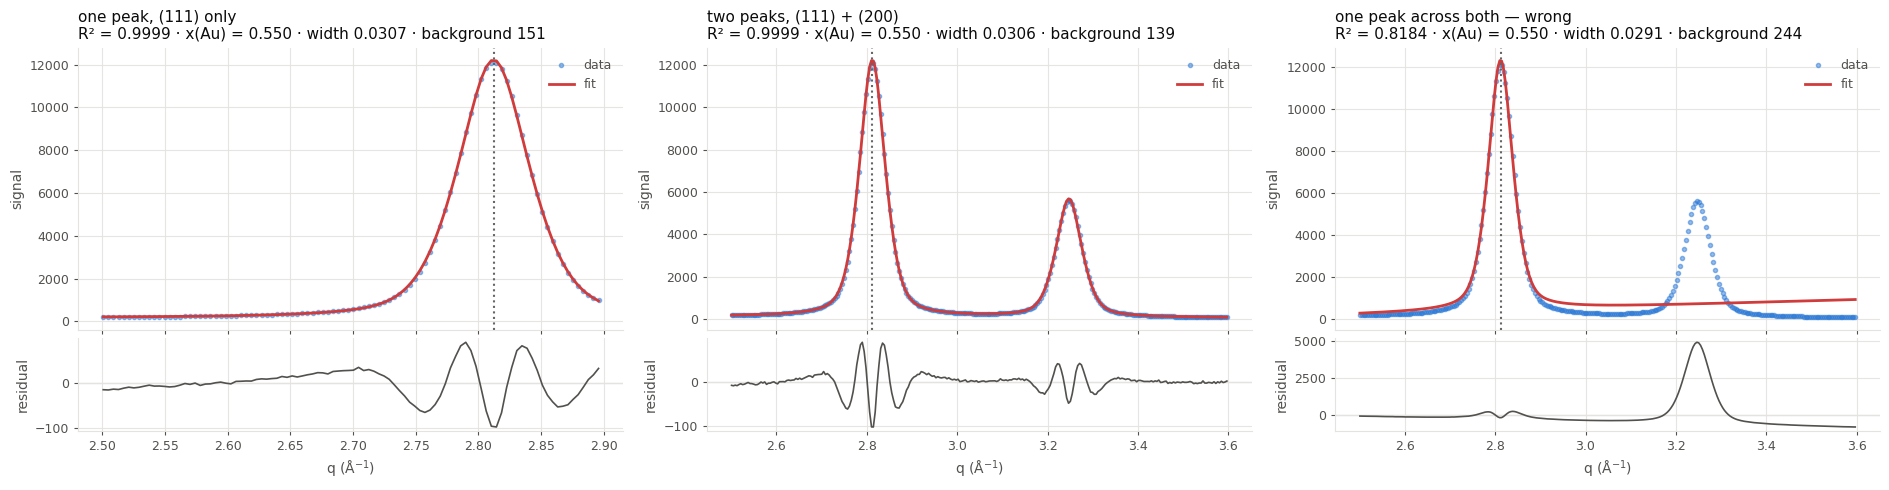

In [19]:
trials = [("one peak, (111) only", dict(n_peaks=1, x_range=(2.5, 2.9))),
          ("two peaks, (111) + (200)", dict(n_peaks=2, x_range=(2.5, 3.6))),
          ("one peak across both — wrong", dict(n_peaks=1, x_range=(2.5, 3.6)))]

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for ax, (label, params) in zip(axes, trials):
    trial = fit_peaks(q, I[0], shape="pseudo_voigt", background="linear", **params)
    x_trial = mat.fraction_from_lattice(mat.lattice_from_q(trial.params["peak1_center"]))
    top, _ = plot_fit(trial.x, trial.y, trial.y_fit, trial.residual, ax=ax,
                      xlabel="q (Å$^{-1}$)",
                      title=(f"{label}\nR² = {trial.r2:.4f} · x(Au) = {x_trial:.3f} · "
                             f"width {trial.params['peak1_width']:.4f} · "
                             f"background {trial.params['baseline']:.0f}"))
    top.axvline(trial.params["peak1_center"], ls=":", color="0.4")
fig.tight_layout()

## The shortcut: the same fit, found for you

`org.fit` finds the measurement and runs the same kernel. It returns a result
and draws nothing; looking at it is `org.plot_fit`, a second call.

<AnalysisResult peak_fit CuAu05: baseline=139.3, baseline_slope=-61.19, peak1_amplitude=1.209e+04>
stored anything? None


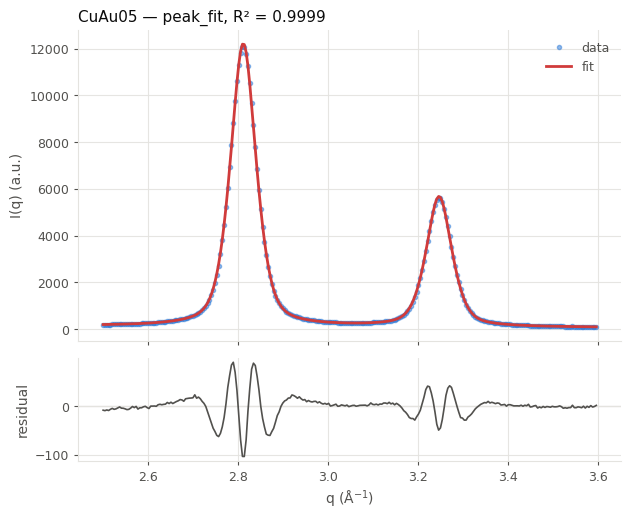

In [20]:
params = dict(x_range=(2.5, 3.6), n_peaks=2, shape="pseudo_voigt", background="linear")

trial = org.fit("CuAu05", "waxs1d", **params)
print(trial)
print("stored anything?", org["CuAu05"].get_derived("waxs1d_peak1_center"))
org.plot_fit(trial);

## Look at the segmentation before trusting a size

Particle sizing pools every micrograph into one histogram, and a histogram
looks plausible whether the outlines were right or not. So segment one frame
and look — `segment` is the analysis, `plot_segmentation` the picture. TEM and
SEM disagree about what a particle *is*, and the outlines show why.

<Segmentation 01.tif: 58 particles, 384×384 px, 0.500 nm/px>
<Segmentation 01.tif: 4 particles, 384×384 px, 2.000 nm/px>


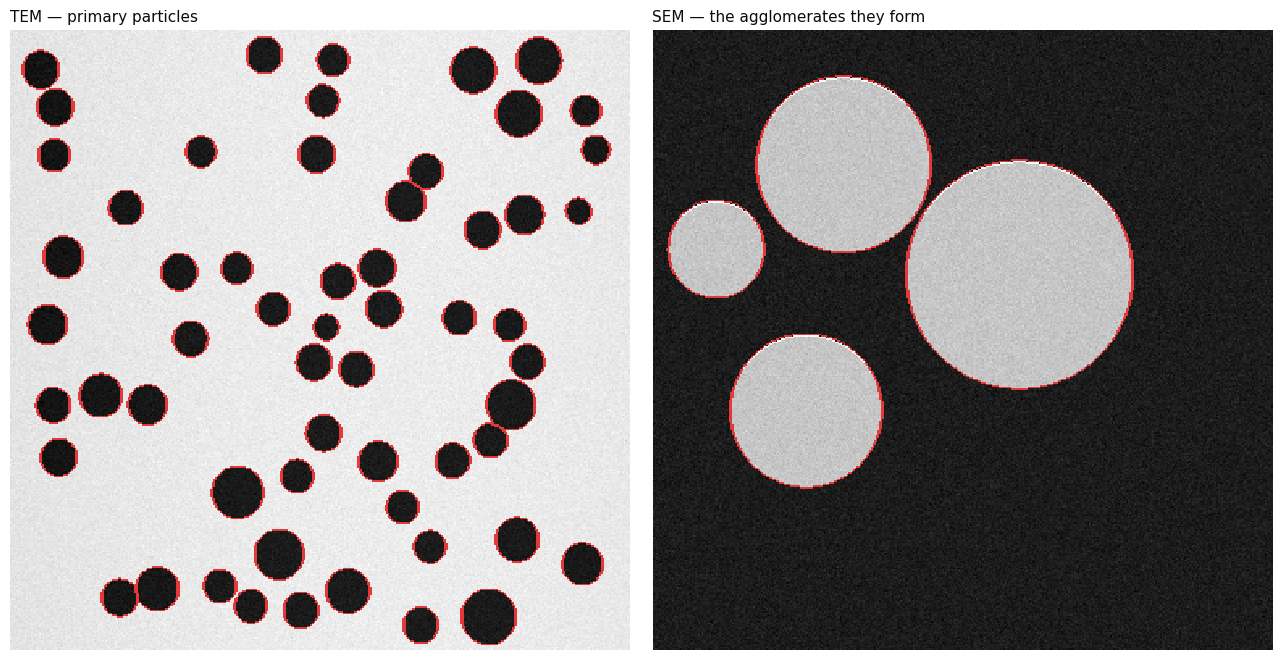

In [21]:
tem_seg = org.segment("CuAu05", "tem")
sem_seg = org.segment("CuAu05", "sem")
print(tem_seg, "\n", sem_seg, sep="")

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
org.plot_segmentation(tem_seg, ax=axes[0], title="TEM — primary particles")
org.plot_segmentation(sem_seg, ax=axes[1], title="SEM — the agglomerates they form")
fig.tight_layout()

## Spend the parameters on the whole campaign

Each batch writes its scalars back as `derived.*` columns, prefixed with the
technique so two analyses cannot overwrite each other, and reports failures
rather than skipping them. `link=True` also saves each fit's **curves** beside
the organizer and links the file onto its sample, so part F can redraw them
without refitting.

| batch | measures |
|---|---|
| WAXS `peak_fit` | the (111) position → lattice parameter → composition |
| UV-Vis `peak_fit` on the last frames | the plasmon band of the grown particles |
| EDS / XPS `curve_metrics` | line areas, gold and copper, bulk and surface |
| TEM / SEM `particle_sizing` | primary particles and agglomerates |
| DLS `curve_metrics` | the hydrodynamic size, at the distribution's maximum |

In [22]:
org.batch("peak_fit", modality="waxs1d", link=True, **params)
org.batch("peak_fit", modality="uvvis", x_range=(470.0, 800.0),
          reduce="last_decile", background="linear", link=True)

org.batch("curve_metrics", modality="eds", prefix="eds_cu_", x_min=7.7, x_max=8.4)
org.batch("curve_metrics", modality="eds", prefix="eds_au_", x_min=9.4, x_max=10.0)
org.batch("curve_metrics", modality="xps", role="cu2p", prefix="xps_cu_", x_min=929, x_max=937)
org.batch("curve_metrics", modality="xps", role="au4f", prefix="xps_au_", x_min=81.5, x_max=86.0)

org.batch("particle_sizing", modality="tem")
org.batch("particle_sizing", modality="sem", max_diameter_nm=500, min_circularity=0.5)
org.batch("curve_metrics", modality="dls", x_min=5, x_max=120)

org.save()
org.results()[["sample_id", "analysis", "modality", "ok", "fit_r2"]].head(6)

peak_fit: 8/8 succeeded, linked 8
peak_fit: 8/8 succeeded, linked 8
curve_metrics: 8/8 succeeded
curve_metrics: 8/8 succeeded
curve_metrics: 8/8 succeeded
curve_metrics: 8/8 succeeded


particle_sizing: 8/8 succeeded


particle_sizing: 8/8 succeeded
curve_metrics: 8/8 succeeded


,sample_id,analysis,modality,ok,fit_r2
0,CuAu01,peak_fit,waxs1d,True,0.999898
1,CuAu01,peak_fit,uvvis,True,0.999937
2,CuAu02,peak_fit,waxs1d,True,0.999901
3,CuAu02,peak_fit,uvvis,True,0.999937
4,CuAu03,peak_fit,waxs1d,True,0.999904
5,CuAu03,peak_fit,uvvis,True,0.999941


---
# E · Compare samples

Ids → table → plot. Each step is a thing you can look at, which is the point:
a one-call comparison that disagrees with your expectation gives you nothing
to inspect.

## Three routes to one composition

Three machines in three rooms. WAXS reads the lattice (Vegard); EDS reads
characteristic X-ray lines (Cliff–Lorimer, with the k-factor the instrument
recorded); XPS reads the same two elements — but only the top few nanometres.

In [23]:
from NanoOrganizer.demo.signals import EDS_K_FACTOR_AU_CU, XPS_RSF

ids = org.ids("`synthesis.status` == 'done'")                 # CuAu09 failed
t = org.table(sample_ids=ids).set_index("sample_id").join(truth).copy()

t["x_WAXS"] = mat.fraction_from_lattice(mat.lattice_from_q(t["derived.waxs1d_peak1_center"]))
t["x_EDS"] = mat.fraction_from_signals(t["derived.eds_au_area"], t["derived.eds_cu_area"],
                                       gold_factor=EDS_K_FACTOR_AU_CU)
t["x_XPS"] = mat.fraction_from_signals(t["derived.xps_au_area"], t["derived.xps_cu_area"],
                                       gold_factor=XPS_RSF["Au 4f7/2"],
                                       copper_factor=XPS_RSF["Cu 2p3/2"])

check = t[["x_Au", "x_WAXS", "x_EDS", "x_XPS", "true_surface_x_Au",
           "derived.uvvis_peak1_center", "true_lspr_nm"]]
check.round(3)

,x_Au,x_WAXS,x_EDS,x_XPS,true_surface_x_Au,derived.uvvis_peak1_center,true_lspr_nm
sample_id,,,,,,,
CuAu01,0.00,0.00,-0.002,0.002,0.000,579.350,580.00
CuAu02,0.10,0.10,0.097,0.133,0.156,574.412,575.08
CuAu03,0.25,0.25,0.234,0.328,0.377,566.577,567.25
CuAu04,0.40,0.40,0.381,0.524,0.571,558.177,558.88
CuAu05,0.55,0.55,0.529,0.683,0.728,549.231,549.97
CuAu06,0.70,0.70,0.687,0.822,0.846,539.693,540.52
CuAu07,0.85,0.85,0.841,0.908,0.932,529.602,530.53
CuAu08,1.00,1.00,0.999,0.996,1.000,519.049,520.00


composition: WAXS within 0.000, EDS within 0.021; XPS sits +0.068 above the bulk on average (true segregation +0.095)
plasmon band within 0.95 nm


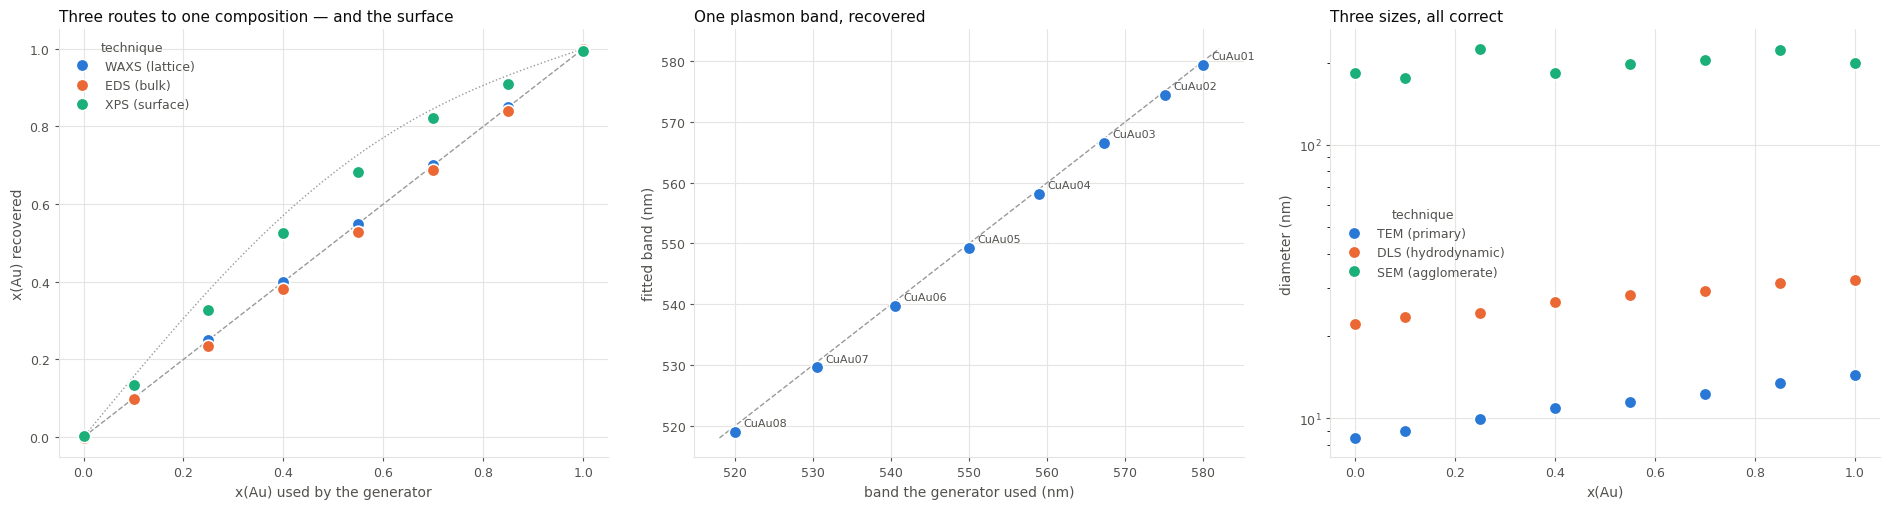

In [24]:
from NanoOrganizer.viz.plots import plot_compare

def long(columns, x, labels):
    """Stack several columns into (x, value, technique) rows for one plot."""
    return pd.concat([pd.DataFrame({"x": t[x], "value": t[c], "technique": label})
                      for c, label in zip(columns, labels)]).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(19, 5.2))

composition = long(["x_WAXS", "x_EDS", "x_XPS"], "x_Au",
                   ["WAXS (lattice)", "EDS (bulk)", "XPS (surface)"])
plot_compare(composition, "x", "value", color_by="technique", ax=axes[0],
             title="Three routes to one composition — and the surface",
             xlabel="x(Au) used by the generator", ylabel="x(Au) recovered")
grid = np.linspace(0, 1, 51)
axes[0].plot(grid, grid, "--", color="0.6", lw=1)                               # bulk
axes[0].plot(grid, [mat.surface_au_fraction(v) for v in grid], ":", color="0.6", lw=1)  # surface

band = t.reset_index()
plot_compare(band, "true_lspr_nm", "derived.uvvis_peak1_center", ax=axes[1],
             title="One plasmon band, recovered",
             xlabel="band the generator used (nm)", ylabel="fitted band (nm)")
axes[1].plot([518, 582], [518, 582], "--", color="0.6", lw=1)

sizes = long(["derived.tem_d_mean", "derived.dls_x_at_max", "derived.sem_d_mean"], "x_Au",
             ["TEM (primary)", "DLS (hydrodynamic)", "SEM (agglomerate)"])
plot_compare(sizes, "x", "value", color_by="technique", logy=True, ax=axes[2],
             title="Three sizes, all correct", xlabel="x(Au)", ylabel="diameter (nm)")
fig.tight_layout()

print(f"composition: WAXS within {(t.x_WAXS - t.x_Au).abs().max():.3f}, "
      f"EDS within {(t.x_EDS - t.x_Au).abs().max():.3f}; "
      f"XPS sits {(t.x_XPS - t.x_Au).mean():+.3f} above the bulk on average "
      f"(true segregation {(t.true_surface_x_Au - t.x_Au).mean():+.3f})")
print(f"plasmon band within {(t['derived.uvvis_peak1_center'] - t.true_lspr_nm).abs().max():.2f} nm")

An electron microscope's X-ray detector and a diffractometer in another room
land on the same composition. XPS does not — and should not: gold has the
lower surface energy and segregates outwards, and the dotted line is how much.
The sizes **disagree by an order of magnitude and all three are right**: TEM
resolves primary particles, DLS reports the solvated object weighted by d⁶,
SEM at this magnification sees the agglomerates. The gaps are information,
which is the argument for keeping them in one table.

## The payoff: the volcano, straight off the table

DFT gave each surface a d-band centre and a CO binding energy; testing gave
each sample a CO partial current. They were written by different people into
different dicts — and they are now columns of one table, so the
structure–property chain is two calls.

best CO producer: CuAu05, x(Au) = 0.55


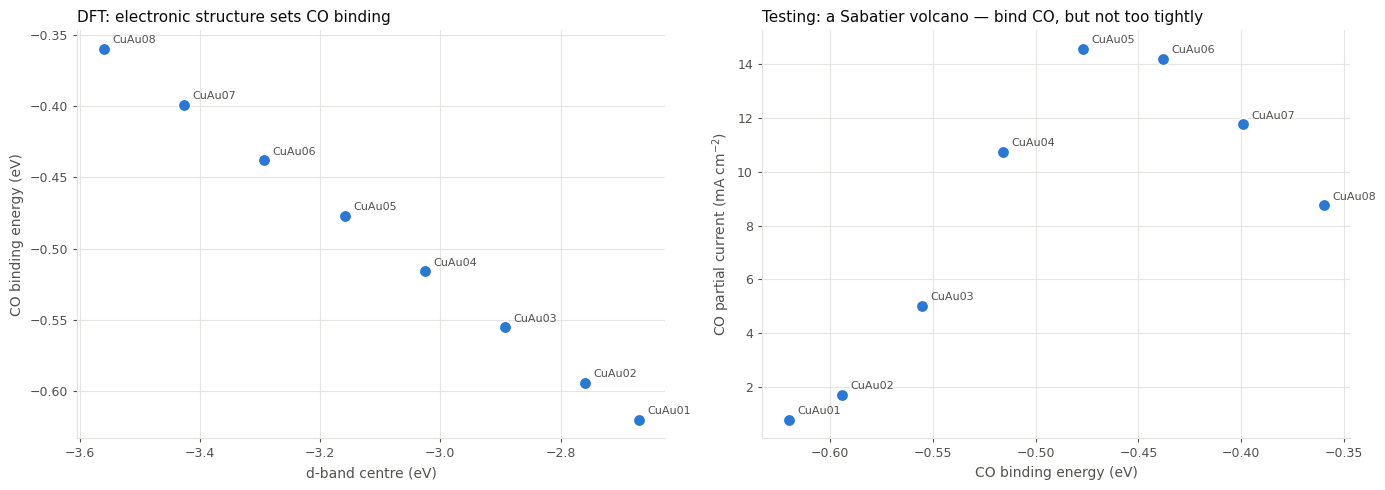

In [25]:
table = org.table(sample_ids=ids)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_compare(table, "computation.descriptors.d_band_centre_eV",
             "computation.descriptors.E_ads_CO_eV", ax=axes[0],
             title="DFT: electronic structure sets CO binding",
             xlabel="d-band centre (eV)", ylabel="CO binding energy (eV)")
plot_compare(table, "computation.descriptors.E_ads_CO_eV",
             "testing.performance.j_CO_mA_cm2", ax=axes[1],
             title="Testing: a Sabatier volcano — bind CO, but not too tightly",
             xlabel="CO binding energy (eV)", ylabel="CO partial current (mA cm$^{-2}$)")
fig.tight_layout()

best = table.set_index("sample_id")["testing.performance.j_CO_mA_cm2"].idxmax()
print(f"best CO producer: {best}, x(Au) = {truth.loc[best, 'x_Au']:.2f}")

---
# F · Reload, and go round again

This is why linking the results was worth doing. Nothing is refitted — the
curves come off disk, and the figure is the one the analysis drew, whether or
not the fitting code still behaves the same way.

In [26]:
later = Organizer(ROOT / "cuau.json")
later.describe();

Cu-Au CO2RR library  (/home/yuzhang/Repos/OrgDemo/CuAu/cuau.json)
  samples       9
                CuAu01, CuAu02, CuAu03, CuAu04, CuAu05, CuAu06, CuAu07, CuAu08  … +1 more
  stages        characterization (8), computation (8), synthesis (9), testing (8)
  Curves (1D)   uvvis, eds, xps, raman, ir, saxs1d, waxs1d, xas, ec, dos, dls
  Images & Maps (2D) saxs2d, tem, sem
  Correlation   xpcs_g2
  Volumes (3D)  tomo
  measurements  160 (160 readable here, 0 not mounted)
  stored fits   peak_fit (uvvis) (8), peak_fit (waxs1d) (8)
  derived       66: dls_area, dls_x_at_max, dls_x_centroid, dls_y_at_max_raw …


In [27]:
from NanoOrganizer.viz.plots import plot_peak_fit

later.results()[["sample_id", "analysis", "modality", "fit_r2"]].tail(4)

,sample_id,analysis,modality,fit_r2
12,CuAu07,peak_fit,waxs1d,0.999912
13,CuAu07,peak_fit,uvvis,0.999932
14,CuAu08,peak_fit,waxs1d,0.999914
15,CuAu08,peak_fit,uvvis,0.999931


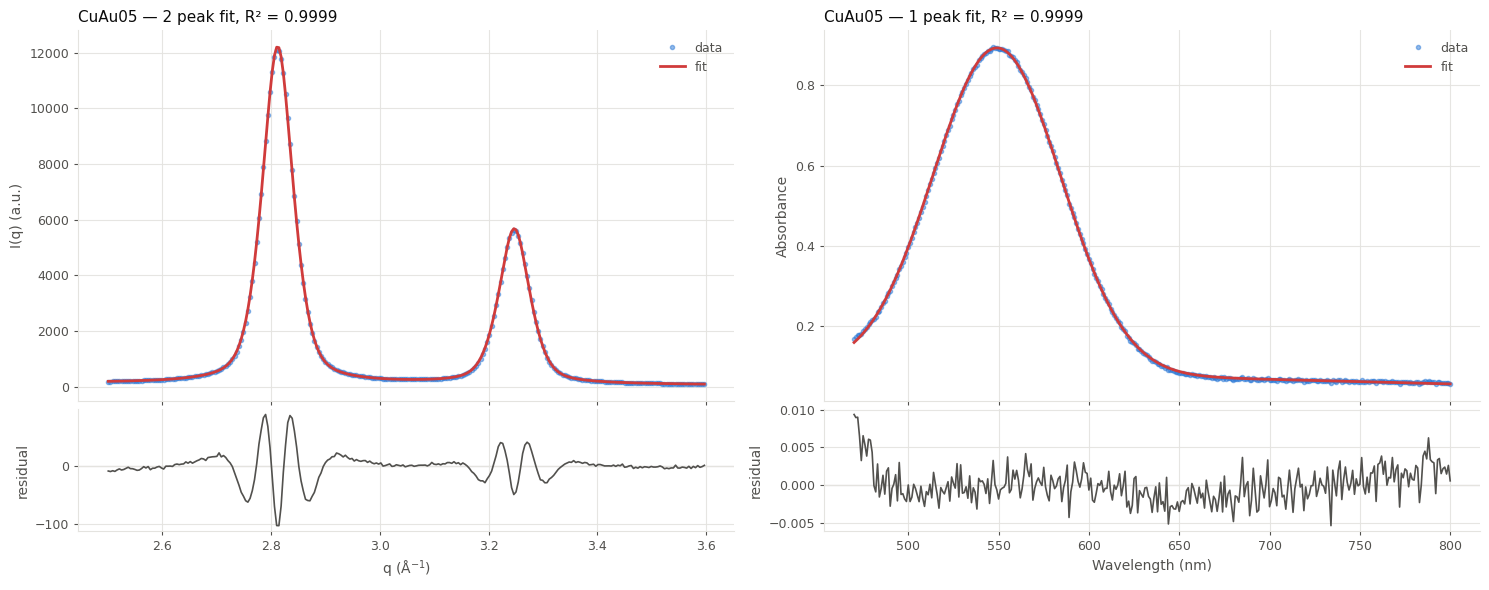

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plot_peak_fit(later.result("CuAu05", "peak_fit", modality="waxs1d"), ax=axes[0])
plot_peak_fit(later.result("CuAu05", "peak_fit", modality="uvvis"), ax=axes[1])
fig.tight_layout()

In [29]:
# A stored fit sits on its sample as a measurement of technique `fit`, so it
# shows up in the catalog beside the techniques it came from. CuAu05 has two,
# so asking for "the fit" is ambiguous — and says so rather than picking one.
try:
    later.plot("CuAu05", "fit")
except KeyError as exc:
    print(exc)

'CuAu05 has 2 matching measurements: CuAu05:fit:analysis-peak-fit-waxs1d, CuAu05:fit:analysis-peak-fit-uvvis. Narrow with stage= or role=.'


## Filter → analyse → new columns → filter again

The derived values are columns now, so the next question is a filter.

In [30]:
later.ids("`derived.tem_d_mean` < 12 and `testing.performance.FE_CO_pct` > 40")

['CuAu04', 'CuAu05']

---

## The whole surface, in one place

| | |
|---|---|
| **A** | `Organizer(path)` · `describe()` · `overview()` · `tree()` · `catalog()` · `ids()` · `filter()` · `subset()` |
| **B** | `data(s, m)` · `data(s, m, frame=/t=/T=)` · `data(s, m, lazy=True)` · `frames(s, m)` |
| **C** | `plot(s, m, ax=)` · or the kernels `plot_series` / `plot_curves` / `plot_image` on B's arrays · `interactive.volume_figure` |
| **D** | `fit_peaks(x, y)` → `plot_fit(…, ax=)` · `fit(s, m)` → `plot_fit(result, ax=)` · `segment()` → `plot_segmentation()` · `batch(key, link=True)` |
| **E** | `ids()` → `table(sample_ids=…)` → `plot_compare(table, x, y, ax=)` |
| **F** | `Organizer(path)` · `results()` · `result(s, key, modality=…)` → `plot_peak_fit(result, ax=)` |

## The same object, with buttons

```bash
streamlit run NanoOrganizer/web_app/Home.py       # or: viz
```

**🎓 Demo** walks through 10 → 11 → 12 with buttons, on the same generator and
the same calls. **📁 Project → Open project** takes the path to `cuau.json`;
the pages drive this same object, so an organizer built here opens there and
the reverse.

| | |
|---|---|
| `10_simulate_data` | a fifteen-technique campaign on disk, and the answer key |
| `11_build_organizer` | `ingest` what was written down, `link` what was not |
| `12_use_organizer` | this |